##zero-shot testing for pneumonia labels

In [ ]:
# mount gogle drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [ ]:
import pandas as pd
import numpy as np
import json
import ast
import torch
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm

In [ ]:


data = pd.read_csv('/content/drive/MyDrive/all_data_all_entities.csv')

In [ ]:

# grab the Pneumonia prompt from file:
try:
    with open('/content/drive/MyDrive/Pneumonia_short.txt') as f:
        prompt = f.read()
except:
    print('FileNotFoundError')

In [ ]:
# def convert_label_to_dict(entry: str) -> dict:
#     return ast.literal_eval(entry)

In [ ]:
def ask_llm_batch(reports, prompt):
    messages = [
        [{"role": "user", "content": prompt + report}]
        for report in reports
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        padding=True,
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=False,
        )

    decoded = tokenizer.batch_decode(
        outputs[:, inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True,
    )

    # CLEAR UNUSED CUDA MEMORY
    del inputs, outputs
    torch.cuda.empty_cache()

    return [(d) for d in decoded]


In [ ]:
def evaluate_responses(df: pd.DataFrame):
    pass


In [ ]:
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
CUDA device count: 1
GPU name: NVIDIA A100-SXM4-40GB


In [ ]:
MODEL_NAME = "microsoft/MediPhi"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="cuda"
)

model.eval()

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Phi3ForCausalLM(
  (model): Phi3Model(
    (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
    (layers): ModuleList(
      (0-31): 32 x Phi3DecoderLayer(
        (self_attn): Phi3Attention(
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (qkv_proj): Linear(in_features=3072, out_features=9216, bias=False)
        )
        (mlp): Phi3MLP(
          (gate_up_proj): Linear(in_features=3072, out_features=16384, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (activation_fn): SiLUActivation()
        )
        (input_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (resid_attn_dropout): Dropout(p=0.0, inplace=False)
        (resid_mlp_dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (norm): Phi3RMSNorm((3072,), eps=1e-05)
    (rotary_emb): Phi3RotaryEmbedding()
  )
  (lm_head): Linear(in_features=3072, out_featur

In [ ]:
data.head()

,Accession,Radiologist_Report,Pneumonia_Pneumonitis,Pneumothorax,Cardiomegaly,Pleural_Effusion,Edema,Rib_Fracture,Unnamed: 8,Info Content Score,Train/Test/Val,TRUE,Unnamed: 12,in training set?,in val?,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,53711709,FINDINGS:\nLines and Tubes: None Mediastinum:...,Likelihood: none\nFocality: NA\nLocation: NA\n...,Presence: absent\nSize: NA\nLaterality: NA\nCh...,Presence: unknown\nChange: stable,Left Presence: absent\nLeft Size: NA\nLeft Cha...,Presence: absent\nSeverity: NA\nChange: NA,Presence: absent\nQuantity: NA\nRib Number: NA...,NaN,6,training,True,NaN,Include,Exclude,NaN,NaN,NaN,NaN,NaN
1,52575111,"FINDINGS:\nDevices, lines and Tubes: Left arm ...",Likelihood: none\nFocality: NA\nLocation: NA\n...,Presence: absent\nSize: NA\nLaterality: NA\nCh...,Presence: present\nChange: stable,Left Presence: present\nLeft Size: medium\nLef...,Presence: present\nSeverity: mild\nChange: inc...,Presence: unknown \nQuantity: unknown \nRib Nu...,NaN,6,validation,True,NaN,Exclude,Include,NaN,NaN,NaN,NaN,NaN
2,53314577,"FINDINGS:\nLines and Tubes: Impella, AICD, Swa...",Likelihood: none\nFocality: NA\nLocation: NA\n...,Presence: absent\nSize: NA\nLaterality: NA\nCh...,Presence: present\nChange: stable,Left Presence: present\nLeft Size: unknown\nLe...,Presence: present\nSeverity: moderate\nChange:...,Presence: unknown \nQuantity: unknown \nRib Nu...,NaN,6,testing,True,NaN,Exclude,Exclude,NaN,NaN,NaN,NaN,NaN
3,54209096,FINDINGS:\nSee IMPRESSION.\n\nIMPRESSION: Devi...,Likelihood: high\nFocality: multifocal\nLocati...,Presence: absent\nSize: NA\nLaterality: NA\nCh...,Presence: unknown\nChange: stable,Left Presence: present\nLeft Size: small\nLeft...,Presence: unknown\nSeverity: unknown\nChange: ...,Presence: unknown \nQuantity: unknown \nRib Nu...,NaN,3,testing,True,NaN,Exclude,Exclude,NaN,NaN,NaN,NaN,NaN
4,52528408,FINDINGS:\nLines and Tubes: None\nMediastinum:...,Likelihood: none\nFocality: NA\nLocation: NA\n...,Presence: absent\nSize: NA\nLaterality: NA\nCh...,Presence: absent\nChange: stable,Left Presence: absent\nLeft Size: NA\nLeft Cha...,Presence: absent \nSeverity: NA \nChange: NA,Presence: unknown \nQuantity: unknown \nRib Nu...,NaN,6,testing,True,NaN,Exclude,Exclude,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Pneumonia;
# Redefine the convert_label_to_dict function to correctly parse the string format
def convert_label_to_dict(entry: str) -> dict:
    if not isinstance(entry, str):
        return {}
    result = {}
    lines = entry.strip().split('\n')
    for line in lines:
        if ':' in line:
            key, value = line.split(':', 1) # Split only on the first colon
            key = key.strip()
            value = value.strip()
            # Adjust key names if they include parentheses as per prompt example
            if key == 'Location(s)':
                key = 'Location'
            elif key == 'Change(s)':
                key = 'Change'
            result[key] = value
    return result

pneumonia_df = data.copy()[['Accession', 'Radiologist_Report', 'Pneumonia_Pneumonitis']]
# parse the labels column into dictionaries
pneumonia_df['Pneumonia_Pneumonitis'] = pneumonia_df['Pneumonia_Pneumonitis'].apply(convert_label_to_dict)

In [ ]:
pneumonia_df.head()

,Accession,Radiologist_Report,Pneumonia_Pneumonitis
0,53711709,FINDINGS:\nLines and Tubes: None Mediastinum:...,"{'Likelihood': 'none', 'Focality': 'NA', 'Loca..."
1,52575111,"FINDINGS:\nDevices, lines and Tubes: Left arm ...","{'Likelihood': 'none', 'Focality': 'NA', 'Loca..."
2,53314577,"FINDINGS:\nLines and Tubes: Impella, AICD, Swa...","{'Likelihood': 'none', 'Focality': 'NA', 'Loca..."
3,54209096,FINDINGS:\nSee IMPRESSION.\n\nIMPRESSION: Devi...,"{'Likelihood': 'high', 'Focality': 'multifocal..."
4,52528408,FINDINGS:\nLines and Tubes: None\nMediastinum:...,"{'Likelihood': 'none', 'Focality': 'NA', 'Loca..."


## Training medi-phi (zero shot)

In [ ]:
def make_predictions(prompt, df: pd.DataFrame, BATCH_SIZE: int):
    results = []

    total = len(df)
    for i in tqdm(
        range(0, total, BATCH_SIZE),
        desc="Running LLM inference",
        unit="reports",
    ):
        batch_reports = df["Radiologist_Report"].iloc[i:i + BATCH_SIZE].tolist()
        batch_results = ask_llm_batch(batch_reports, prompt)
        results.extend(batch_results)

    return results

In [ ]:
predictions_out = make_predictions(prompt, pneumonia_df, 50)

Running LLM inference: 100%|██████████| 70/70 [06:00<00:00,  5.15s/reports]


In [ ]:
import re

def extract_json_from_llm(text: str):
    if not isinstance(text, str):
        return None

    result = {
        "focality": None,
        "likelihood": None,
        "change": None,
    }

    # normalize text
    text = text.lower()

    # patterns that survive truncation
    patterns = {
        "likelihood": r'"likelihood"\s*:\s*"([^"]+)"',
        "focality": r'"focality"\s*:\s*"([^"]+)"',
        "change": r'"change\(s\)"\s*:\s*"([^"]+)"|\"change\"\s*:\s*\"([^\"]+)\"',
    }

    for key, pattern in patterns.items():
        match = re.search(pattern, text)
        if match:
            # some patterns have multiple groups
            value = next(g for g in match.groups() if g is not None)
            result[key] = value.strip()

    # return None only if absolutely nothing was recovered
    if all(v is None for v in result.values()):
        return None

    return result


In [ ]:
extract_json_from_llm(predictions_out[100])

{'focality': 'na', 'likelihood': 'none', 'change': None}

In [ ]:
pneumonia_df["llm_predictions"] = [extract_json_from_llm(text) for text in predictions_out]

In [ ]:
pneumonia_df.head(30)

,Accession,Radiologist_Report,Pneumonia_Pneumonitis,llm_predictions
0,53711709,FINDINGS:\nLines and Tubes: None Mediastinum:...,"{'Likelihood': 'none', 'Focality': 'NA', 'Loca...","{'focality': 'na', 'likelihood': 'none', 'chan..."
1,52575111,"FINDINGS:\nDevices, lines and Tubes: Left arm ...","{'Likelihood': 'none', 'Focality': 'NA', 'Loca...","{'focality': 'na', 'likelihood': 'low', 'chang..."
2,53314577,"FINDINGS:\nLines and Tubes: Impella, AICD, Swa...","{'Likelihood': 'none', 'Focality': 'NA', 'Loca...","{'focality': 'na', 'likelihood': 'low', 'chang..."
3,54209096,FINDINGS:\nSee IMPRESSION.\n\nIMPRESSION: Devi...,"{'Likelihood': 'high', 'Focality': 'multifocal...","{'focality': 'multifocal', 'likelihood': 'low'..."
4,52528408,FINDINGS:\nLines and Tubes: None\nMediastinum:...,"{'Likelihood': 'none', 'Focality': 'NA', 'Loca...","{'focality': 'na', 'likelihood': 'none', 'chan..."
5,53819581,FINDINGS:\nSee impression.\n\nIMPRESSION: Stab...,"{'Likelihood': 'low', 'Focality': 'focal', 'Lo...","{'focality': 'na', 'likelihood': 'low', 'chang..."
6,54001618,FINDINGS:\nSee impression\n\nIMPRESSION: Stabl...,"{'Likelihood': 'low', 'Focality': 'multifocal'...","{'focality': 'multifocal', 'likelihood': 'low'..."
7,54329587,FINDINGS:\nLines and Tubes: Interval mobile of...,"{'Likelihood': 'none', 'Focality': 'NA', 'Loca...","{'focality': 'na', 'likelihood': 'low', 'chang..."
8,54342556,FINDINGS:\n11/11/2021 at 2008 hours Lines and...,"{'Likelihood': 'low', 'Focality': 'multifocal'...","{'focality': 'multifocal', 'likelihood': 'low'..."
9,53903167,FINDINGS:\nSee impression\n\nIMPRESSION: Stabl...,"{'Likelihood': 'none', 'Focality': 'NA', 'Loca...","{'focality': 'na', 'likelihood': 'low', 'chang..."


###  Zero-shot accuracy confusion matricies for **Focality and Likelihood**

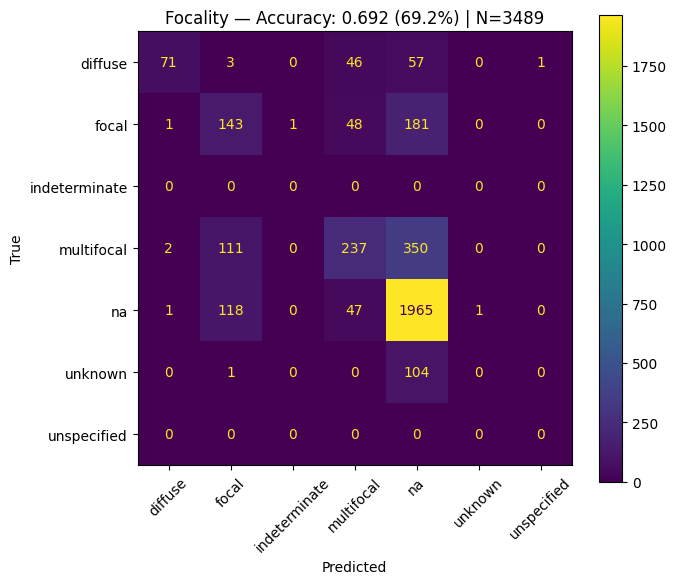

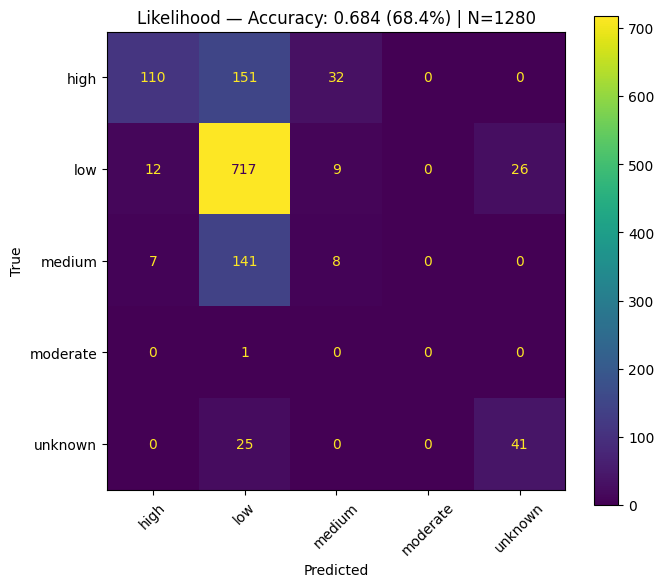

⚠️ Change: No rows where BOTH true and predicted are present. Skipping plot.
⚠️ Location: No rows where BOTH true and predicted are present. Skipping plot.


,accuracy
focality,0.692462
likelihood,0.684375
change,NaN
location,NaN


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

def plot_confusion_matrix_with_accuracy(df, true_col, pred_col, title):
    sub = df[[true_col, pred_col]].dropna()

    # ✅ nothing to compare
    if sub.empty:
        print(f"⚠️ {title}: No rows where BOTH true and predicted are present. Skipping plot.")
        return None, np.nan, []

    y_true = sub[true_col].astype(str)
    y_pred = sub[pred_col].astype(str)

    labels = sorted(set(y_true.unique()).union(set(y_pred.unique())))

    # ✅ extra safety
    if len(labels) == 0:
        print(f"⚠️ {title}: No labels found after cleaning. Skipping plot.")
        return None, np.nan, []

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, xticks_rotation=45, values_format="d", colorbar=True)

    ax.set_title(f"{title} — Accuracy: {acc:.3f} ({acc*100:.1f}%) | N={len(sub)}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()

    return cm, acc, labels
results = {}
for f in ["focality", "likelihood", "change", "location"]:
    cm, acc, labels = plot_confusion_matrix_with_accuracy(
        pneumonia_df, f"true_{f}", f"pred_{f}", f.capitalize()
    )
    results[f] = {"accuracy": acc, "labels": labels, "cm": cm}

pd.DataFrame({k: {"accuracy": v["accuracy"]} for k, v in results.items()}).T


In [ ]:
import pandas as pd

csv_path ='/content/drive/MyDrive//processed_data_all_entities_exploded.csv'
processed_all = pd.read_csv(csv_path)

processed_all.head()


,Accession,Radiologist_Report,Pneumonia_Pneumonitis__Likelihood,Pneumonia_Pneumonitis__Focality,Pneumonia_Pneumonitis__Location,Pneumonia_Pneumonitis__Change,Pneumothorax__Presence,Pneumothorax__Size,Pneumothorax__Laterality,Pneumothorax__Change,...,Edema__Severity,Edema__Change,Rib_Fracture__Presence,Rib_Fracture__Quantity,Rib_Fracture__Rib Number,Rib_Fracture__Laterality,Rib_Fracture__Location,Rib_Fracture__Chronicity,Rib_Fracture__Displacement,Rib_Fracture__Change
0,53711709,FINDINGS:\nLines and Tubes: None Mediastinum:...,none,NaN,NaN,NaN,absent,NaN,NaN,NaN,...,NaN,NaN,absent,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,52575111,"FINDINGS:\nDevices, lines and Tubes: Left arm ...",none,NaN,NaN,NaN,absent,NaN,NaN,NaN,...,mild,increased,unknown,unknown,unknown,unknown,unknown,unknown,unknown,stable
2,53314577,"FINDINGS:\nLines and Tubes: Impella, AICD, Swa...",none,NaN,NaN,NaN,absent,NaN,NaN,NaN,...,moderate,stable,unknown,unknown,unknown,unknown,unknown,unknown,unknown,stable
3,54209096,FINDINGS:\nSee IMPRESSION.\n\nIMPRESSION: Devi...,high,multifocal,"left mid, left lower, right mid, right lower","stable, stable, stable, stable",absent,NaN,NaN,NaN,...,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,stable
4,52528408,FINDINGS:\nLines and Tubes: None\nMediastinum:...,none,NaN,NaN,NaN,absent,NaN,NaN,NaN,...,NaN,NaN,unknown,unknown,unknown,unknown,unknown,unknown,unknown,stable


In [ ]:
truth = processed_all.copy()  # this is your processed_data_all_entities_exploded.csv loaded already

TRUE_COLS = {
    "Likelihood": "Pneumonia_Pneumonitis__Likelihood",
    "Focality":  "Pneumonia_Pneumonitis__Focality",
    "Change":    "Pneumonia_Pneumonitis__Change",
    "Location":  "Pneumonia_Pneumonitis__Location",
}


In [ ]:
preds = pneumonia_df.copy()  # <-- change this to whatever your output/results df is

PRED_COLS = {
    "Likelihood": "pred_likelihood",
    "Focality":  "pred_focality",
    "Change":    "pred_change",
    "Location":  "pred_location",
}


NameError: name 'pneumonia_df' is not defined

In [ ]:
df_eval = truth.merge(
    preds[["Accession"] + list(PRED_COLS.values())],
    on="Accession",
    how="inner"
)

df_eval.shape, df_eval.head()


((3489, 34),
    Accession                                 Radiologist_Report  \
 0   53711709  FINDINGS:\nLines and Tubes: None  Mediastinum:...   
 1   52575111  FINDINGS:\nDevices, lines and Tubes: Left arm ...   
 2   53314577  FINDINGS:\nLines and Tubes: Impella, AICD, Swa...   
 3   54209096  FINDINGS:\nSee IMPRESSION.\n\nIMPRESSION: Devi...   
 4   52528408  FINDINGS:\nLines and Tubes: None\nMediastinum:...   
 
   Pneumonia_Pneumonitis__Likelihood Pneumonia_Pneumonitis__Focality  \
 0                              none                             NaN   
 1                              none                             NaN   
 2                              none                             NaN   
 3                              high                      multifocal   
 4                              none                             NaN   
 
                 Pneumonia_Pneumonitis__Location  \
 0                                           NaN   
 1                                     

In [ ]:
import re
import numpy as np
import pandas as pd

def extract_side_text(x, side):
    """
    Extract the portion of a messy multi-part string that corresponds to 'left' or 'right'.
    Returns None if nothing for that side.
    """
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    if s in ("", "none", "nan"):
        return None

    # Normalize separators
    s = s.replace("|", ";").replace("/", ";")

    # Split into segments on common delimiters
    parts = re.split(r"[;,\n]+", s)
    parts = [p.strip() for p in parts if p.strip()]

    # Keep only segments mentioning the requested side
    if side == "left":
        keep = [p for p in parts if re.search(r"\bleft\b|\bl\b(?![a-z])", p)]
        drop = [p for p in keep if re.search(r"\bright\b|\br\b(?![a-z])", p)]
        keep = [p for p in keep if p not in drop]
    else:  # right
        keep = [p for p in parts if re.search(r"\bright\b|\br\b(?![a-z])", p)]
        drop = [p for p in keep if re.search(r"\bleft\b|\bl\b(?![a-z])", p)]
        keep = [p for p in keep if p not in drop]

    if not keep:
        return None

    # Remove the side token from the text to reduce label explosion
    cleaned = []
    for p in keep:
        p = re.sub(r"\bleft\b|\bright\b", "", p).strip()
        p = re.sub(r"^\W+|\W+$", "", p).strip()
        cleaned.append(p)

    out = "; ".join([c for c in cleaned if c])
    return out if out else None


###  Zero-shot accuracy confusion matricies for **Location and Change**

In [ ]:
# Location
df_eval["true_location_left"]  = df_eval[TRUE_COLS["Location"]].apply(lambda x: extract_side_text(x, "left"))
df_eval["true_location_right"] = df_eval[TRUE_COLS["Location"]].apply(lambda x: extract_side_text(x, "right"))

df_eval["pred_location_left"]  = df_eval[PRED_COLS["Location"]].apply(lambda x: extract_side_text(x, "left"))
df_eval["pred_location_right"] = df_eval[PRED_COLS["Location"]].apply(lambda x: extract_side_text(x, "right"))

# Change
df_eval["true_change_left"]  = df_eval[TRUE_COLS["Change"]].apply(lambda x: extract_side_text(x, "left"))
df_eval["true_change_right"] = df_eval[TRUE_COLS["Change"]].apply(lambda x: extract_side_text(x, "right"))

df_eval["pred_change_left"]  = df_eval[PRED_COLS["Change"]].apply(lambda x: extract_side_text(x, "left"))
df_eval["pred_change_right"] = df_eval[PRED_COLS["Change"]].apply(lambda x: extract_side_text(x, "right"))


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

def plot_cm_acc(df, true_col, pred_col, title, missing="__missing__"):
    sub = df[[true_col, pred_col]].copy()

    for c in [true_col, pred_col]:
        sub[c] = sub[c].astype(str).str.strip()
        sub[c] = sub[c].replace(["nan", "None", "none", ""], np.nan)

    sub[true_col] = sub[true_col].fillna(missing).astype(str)
    sub[pred_col] = sub[pred_col].fillna(missing).astype(str)

    y_true, y_pred = sub[true_col], sub[pred_col]
    labels = sorted(set(y_true.unique()).union(set(y_pred.unique())))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(7,6))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(
        ax=ax, xticks_rotation=45, values_format="d", colorbar=True
    )
    ax.set_title(f"{title} — Accuracy: {acc:.3f} ({acc*100:.1f}%) | N={len(sub)}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()

    return acc


/tmp/ipython-input-914425404.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub[c] = sub[c].replace(["nan", "None", "none", ""], np.nan)


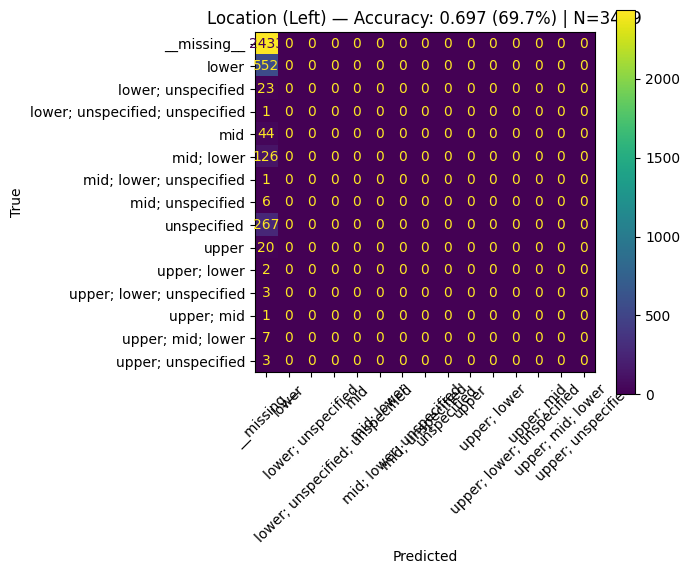

/tmp/ipython-input-914425404.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub[c] = sub[c].replace(["nan", "None", "none", ""], np.nan)


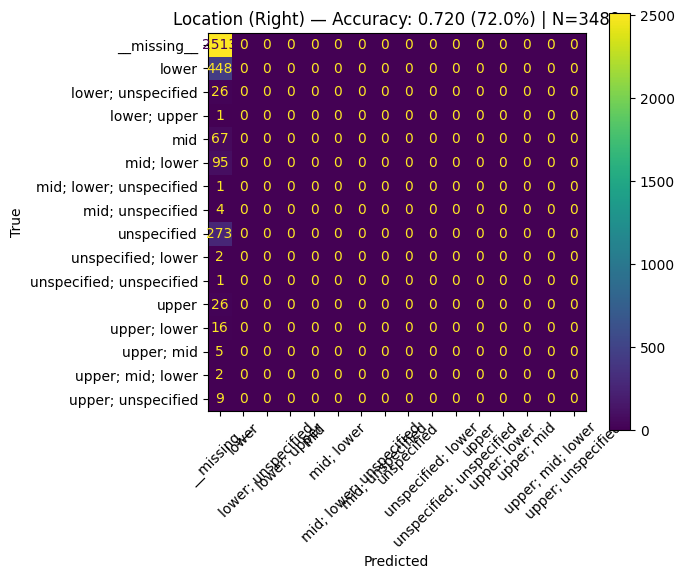

/tmp/ipython-input-914425404.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub[c] = sub[c].replace(["nan", "None", "none", ""], np.nan)
/tmp/ipython-input-914425404.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub[c] = sub[c].replace(["nan", "None", "none", ""], np.nan)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  w

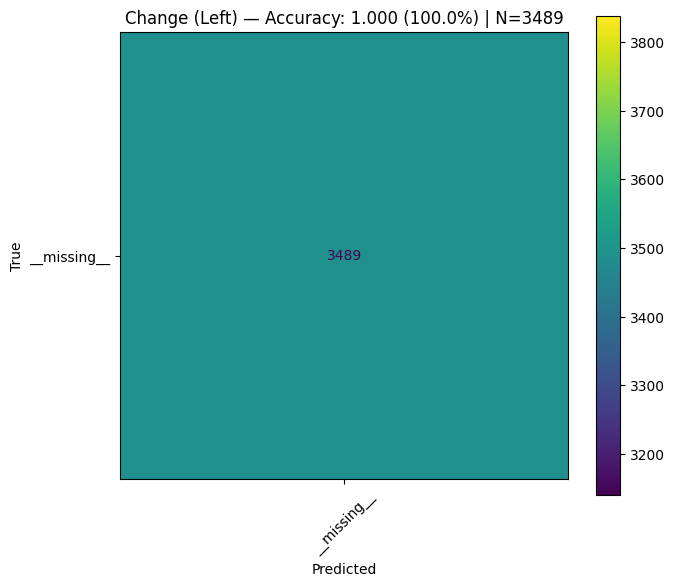

/tmp/ipython-input-914425404.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub[c] = sub[c].replace(["nan", "None", "none", ""], np.nan)
/tmp/ipython-input-914425404.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub[c] = sub[c].replace(["nan", "None", "none", ""], np.nan)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  w

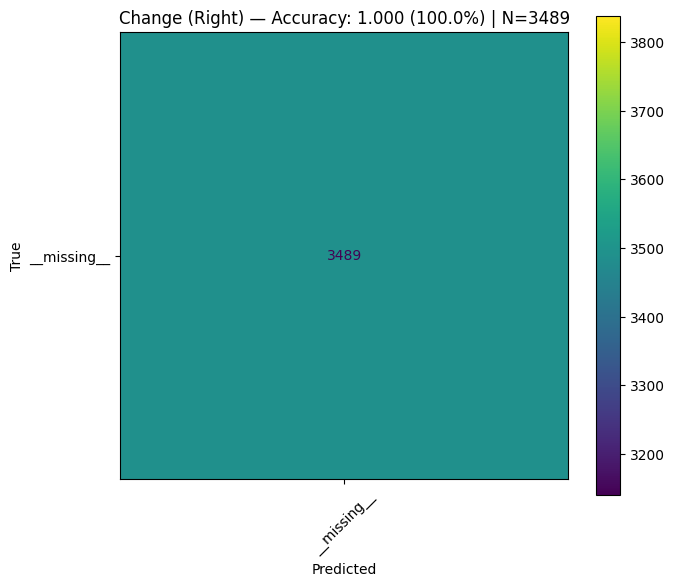

{'Location (Left)': 0.6973344797936372,
 'Location (Right)': 0.7202636858698768,
 'Change (Left)': 1.0,
 'Change (Right)': 1.0}

In [ ]:
acc_lr = {}

acc_lr["Location (Left)"]  = plot_cm_acc(df_eval, "true_location_left",  "pred_location_left",  "Location (Left)")
acc_lr["Location (Right)"] = plot_cm_acc(df_eval, "true_location_right", "pred_location_right", "Location (Right)")

acc_lr["Change (Left)"]  = plot_cm_acc(df_eval, "true_change_left",  "pred_change_left",  "Change (Left)")
acc_lr["Change (Right)"] = plot_cm_acc(df_eval, "true_change_right", "pred_change_right", "Change (Right)")

acc_lr


## Fine-tuning using LoRA optimizer


In [ ]:
pneu_df = processed_all[[
    "Accession",
    "Radiologist_Report",
    "Pneumonia_Pneumonitis__Likelihood",
    "Pneumonia_Pneumonitis__Focality",
    "Pneumonia_Pneumonitis__Change",
    "Pneumonia_Pneumonitis__Location",
]].copy()

pneu_df.head()


,Accession,Radiologist_Report,Pneumonia_Pneumonitis__Likelihood,Pneumonia_Pneumonitis__Focality,Pneumonia_Pneumonitis__Change,Pneumonia_Pneumonitis__Location
0,53711709,FINDINGS:\nLines and Tubes: None Mediastinum:...,none,NaN,NaN,NaN
1,52575111,"FINDINGS:\nDevices, lines and Tubes: Left arm ...",none,NaN,NaN,NaN
2,53314577,"FINDINGS:\nLines and Tubes: Impella, AICD, Swa...",none,NaN,NaN,NaN
3,54209096,FINDINGS:\nSee IMPRESSION.\n\nIMPRESSION: Devi...,high,multifocal,"stable, stable, stable, stable","left mid, left lower, right mid, right lower"
4,52528408,FINDINGS:\nLines and Tubes: None\nMediastinum:...,none,NaN,NaN,NaN


In [ ]:
!pip -q install -U transformers accelerate peft datasets bitsandbytes scikit-learn

import re
import ast
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training


In [ ]:

processed_all = pd.read_csv(csv_path)

pneu_df = processed_all[[
    "Accession",
    "Radiologist_Report",
    "Pneumonia_Pneumonitis__Likelihood",
    "Pneumonia_Pneumonitis__Focality",
    "Pneumonia_Pneumonitis__Change",
    "Pneumonia_Pneumonitis__Location",
]].copy()

# Basic cleanup (optional)
for c in [
    "Pneumonia_Pneumonitis__Likelihood",
    "Pneumonia_Pneumonitis__Focality",
    "Pneumonia_Pneumonitis__Change",
    "Pneumonia_Pneumonitis__Location",
]:
    pneu_df[c] = pneu_df[c].astype(str).str.strip().replace(["nan", "None", "none", ""], np.nan)

pneu_df.head()


,Accession,Radiologist_Report,Pneumonia_Pneumonitis__Likelihood,Pneumonia_Pneumonitis__Focality,Pneumonia_Pneumonitis__Change,Pneumonia_Pneumonitis__Location
0,53711709,FINDINGS:\nLines and Tubes: None Mediastinum:...,NaN,NaN,NaN,NaN
1,52575111,"FINDINGS:\nDevices, lines and Tubes: Left arm ...",NaN,NaN,NaN,NaN
2,53314577,"FINDINGS:\nLines and Tubes: Impella, AICD, Swa...",NaN,NaN,NaN,NaN
3,54209096,FINDINGS:\nSee IMPRESSION.\n\nIMPRESSION: Devi...,high,multifocal,"stable, stable, stable, stable","left mid, left lower, right mid, right lower"
4,52528408,FINDINGS:\nLines and Tubes: None\nMediastinum:...,NaN,NaN,NaN,NaN


In [ ]:
train_df, temp_df = train_test_split(pneu_df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))


2791 349 349


In [ ]:
def norm(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    s = str(x).strip().lower()
    return None if s in ("", "none", "nan", "null") else s

PNEU_PROMPT = """
Extract Pneumonia/Pneumonitis attributes from the radiology report.

Return ONLY a Python dictionary with exactly these keys:
{"Likelihood": ..., "Focality": ..., "Change": ..., "Location": ...}

No extra text.
Report:
""".strip()

def make_label_dict(r):
    return {
        "Likelihood": norm(r["Pneumonia_Pneumonitis__Likelihood"]),
        "Focality":  norm(r["Pneumonia_Pneumonitis__Focality"]),
        "Change":    norm(r["Pneumonia_Pneumonitis__Change"]),
        "Location":  norm(r["Pneumonia_Pneumonitis__Location"]),
    }

def make_training_text(report, label_dict):
    return f"""{PNEU_PROMPT}
{report}

### Response:
{label_dict}""".strip()

train_df["training_text"] = train_df.apply(lambda r: make_training_text(r["Radiologist_Report"], make_label_dict(r)), axis=1)
val_df["training_text"]   = val_df.apply(lambda r: make_training_text(r["Radiologist_Report"], make_label_dict(r)), axis=1)


In [ ]:
!pip -q install -U transformers accelerate peft datasets bitsandbytes scikit-learn

import torch, re, ast, json
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments, DataCollatorForLanguageModeling
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

MODEL_NAME = "microsoft/MediPhi"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    torch_dtype=torch.float16,
)

# tokenization + masking (train only on the response)
marker = "### Response:"
marker_ids = tokenizer(marker, add_special_tokens=False)["input_ids"]

def tokenize_and_mask(example):
    text = example["training_text"]
    tok = tokenizer(text, truncation=True, max_length=2048, padding=False)
    input_ids = tok["input_ids"]
    labels = input_ids.copy()

    start = None
    for i in range(len(input_ids) - len(marker_ids) + 1):
        if input_ids[i:i+len(marker_ids)] == marker_ids:
            start = i + len(marker_ids)
            break

    if start is not None:
        for j in range(start):
            labels[j] = -100

    tok["labels"] = labels
    return tok

train_ds = Dataset.from_pandas(train_df[["training_text"]]).map(tokenize_and_mask, remove_columns=["training_text"])
val_ds   = Dataset.from_pandas(val_df[["training_text"]]).map(tokenize_and_mask, remove_columns=["training_text"])

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# LoRA
model = prepare_model_for_kbit_training(model)
lora_cfg = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","k_proj","v_proj","o_proj"],  # matches many Phi variants
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Map:   0%|          | 0/2791 [00:00<?, ? examples/s]

Map:   0%|          | 0/349 [00:00<?, ? examples/s]

trainable params: 3,145,728 || all params: 3,824,225,280 || trainable%: 0.0823


In [ ]:
training_args = TrainingArguments(
    output_dir="./pneumonia_lora_outputs",
    num_train_epochs=3,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    fp16=True,          # set False if fp16 errors
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
)

trainer.train()


Step,Training Loss,Validation Loss
50,0.702864,0.686065
100,0.579017,0.592693
150,0.551085,0.546427
200,0.561374,0.523228
250,0.503518,0.509891
300,0.487291,0.494996
350,0.561375,0.480259
400,0.489487,0.472883
450,0.444788,0.469478
500,0.484700,0.461135


TrainOutput(global_step=1047, training_loss=0.5096471655790079, metrics={'train_runtime': 1488.7768, 'train_samples_per_second': 5.624, 'train_steps_per_second': 0.703, 'total_flos': 4.154434868267827e+16, 'train_loss': 0.5096471655790079, 'epoch': 3.0})

In [ ]:
@torch.no_grad()
def predict_dicts(df, batch_size=8, max_new_tokens=128):
    model.eval()
    outs = []
    for i in range(0, len(df), batch_size):
        batch = df.iloc[i:i+batch_size]
        prompts = [f"{PNEU_PROMPT}\n{r}\n\n### Response:\n" for r in batch["Radiologist_Report"].tolist()]
        toks = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=2048).to(model.device)

        gen = model.generate(
            **toks,
            do_sample=False,
            max_new_tokens=max_new_tokens,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

        texts = tokenizer.batch_decode(gen, skip_special_tokens=True)
        outs.extend([extract_dict(t) for t in texts])
    return outs


def normalize_pred_dict(d):
    """Force keys to consistent names so pred_likelihood etc always exist."""
    if not isinstance(d, dict):
        d = {}

    # lowercase keys for matching
    d2 = {str(k).strip().lower(): v for k, v in d.items()}

    return {
        "pred_likelihood": norm(d2.get("likelihood")),
        "pred_focality":  norm(d2.get("focality")),
        "pred_change":    norm(d2.get("change")),
        "pred_location":  norm(d2.get("location")),
    }


preds = predict_dicts(test_df, batch_size=8, max_new_tokens=128)

# make sure the prediction columns always exist
pred_cols = pd.DataFrame([normalize_pred_dict(d) for d in preds])

eval_df = pd.concat([test_df.reset_index(drop=True), pred_cols], axis=1)
eval_df.head()


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

def plot_cm_acc(df, true_col, pred_col, title, missing="__missing__"):
    y_true = df[true_col].apply(norm).fillna(missing).astype(str)
    y_pred = df[pred_col].apply(norm).fillna(missing).astype(str)

    labels = sorted(set(y_true.unique()).union(set(y_pred.unique())))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(
        ax=ax, xticks_rotation=45, values_format="d", colorbar=True
    )
    ax.set_title(f"{title} — Accuracy: {acc:.3f} ({acc*100:.1f}%) | N={len(y_true)}")
    plt.tight_layout()
    plt.show()

    return acc

TRUE_COLS = {
    "Likelihood": "Pneumonia_Pneumonitis__Likelihood",
    "Focality":  "Pneumonia_Pneumonitis__Focality",
    "Change":    "Pneumonia_Pneumonitis__Change",
    "Location":  "Pneumonia_Pneumonitis__Location",
}

accs = {}
accs["Likelihood"] = plot_cm_acc(eval_df, TRUE_COLS["Likelihood"], "pred_likelihood", "Likelihood")
accs["Focality"]   = plot_cm_acc(eval_df, TRUE_COLS["Focality"],   "pred_focality",   "Focality")
accs["Change"]     = plot_cm_acc(eval_df, TRUE_COLS["Change"],     "pred_change",     "Change")
accs["Location"]   = plot_cm_acc(eval_df, TRUE_COLS["Location"],   "pred_location",   "Location")

accs
